11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testinag images : (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9295 - loss: 0.2389 - val_accuracy: 0.9767 - val_loss: 0.0829
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.9791 - loss: 0.0710 - val_accuracy: 0.9863 - val_loss: 0.0510
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9865 - loss: 0.0456 - val_accuracy: 0.9850 - val_loss: 0.0504
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9899 - loss: 0.0335 - val_accuracy: 0.9847 - val_loss: 0.0514
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9929 - loss: 0.0246 - val_accuracy: 0.9862 - val_loss: 0.0552
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9855 - loss: 0.0418
Test Accuracy: 0.9854999780654907


Saving Wallpaper Pixel art Spiderman.jpg to Wallpaper Pixel art Spiderman.jpg


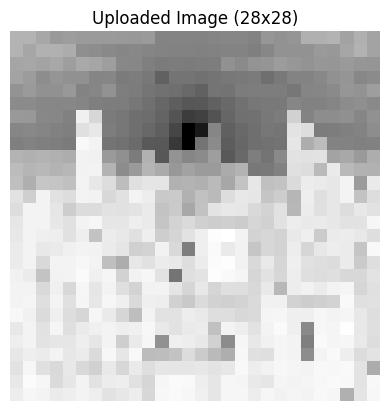

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Digit: 3


In [ ]:
#Introduction to Dl for Image classification

import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from google.colab import files

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Testinag images :", X_test.shape)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

X_train = X_train / 255.0
X_test  = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img

img_resized = cv2.resize(img_gray, (28, 28))

img_resized = 255 - img_resized

img_resized = img_resized / 255.0

img_input = img_resized.reshape(1, 28, 28, 1)

plt.imshow(img_resized, cmap='gray')
plt.title("Uploaded Image (28x28)")
plt.axis('off')
plt.show()

prediction = model.predict(img_input)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)
